In [8]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

cost = yf.Ticker("COST")
cost_data = cost.history(period="max")

cost_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-07-09 00:00:00-04:00,7.120016,7.369841,7.036741,7.328204,1116800,0.00,0.0
1986-07-10 00:00:00-04:00,7.369842,7.411480,7.120017,7.286567,595600,0.00,0.0
1986-07-11 00:00:00-04:00,7.244931,7.286569,7.036744,7.036744,800400,0.00,0.0
1986-07-14 00:00:00-04:00,7.078378,7.078378,6.745278,6.828553,738000,0.00,0.0
1986-07-15 00:00:00-04:00,6.786915,6.786915,6.203990,6.620365,2059200,0.00,0.0
...,...,...,...,...,...,...,...
2026-04-27 00:00:00-04:00,1007.168572,1012.940166,995.185959,996.563965,1620400,0.00,0.0
2026-04-28 00:00:00-04:00,1009.015855,1011.182755,984.571345,992.559753,1776000,0.00,0.0
2026-04-29 00:00:00-04:00,986.937898,997.522515,983.692607,997.222961,1516900,0.00,0.0


In [9]:
# Summary Statistics
cost_data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,10031.000000,10031.000000,10031.000000,10031.000000,1.003100e+04,10031.000000,10031.000000
mean,135.531925,136.771515,134.295459,135.604755,2.856969e+06,0.008782,0.000399
std,229.871748,231.890510,227.825313,229.992426,2.301082e+06,0.218965,0.028239
min,3.997203,4.080478,3.913928,4.018022,4.640000e+04,0.000000,0.000000
25%,8.702244,8.827156,8.535694,8.702244,1.523300e+06,0.000000,0.000000
50%,33.741481,34.155355,33.262947,33.809139,2.279300e+06,0.000000,0.000000
75%,128.920060,129.788249,128.143830,128.968742,3.635600e+06,0.000000,0.000000
max,1069.061231,1070.799152,1060.649633,1069.438599,5.677350e+07,15.000000,2.000000


In [11]:
# Stock Date Range Check
cost_data.index.min(),cost_data.index.max()

(Timestamp('1986-07-09 00:00:00-0400', tz='America/New_York'),
 Timestamp('2026-05-01 00:00:00-0400', tz='America/New_York'))

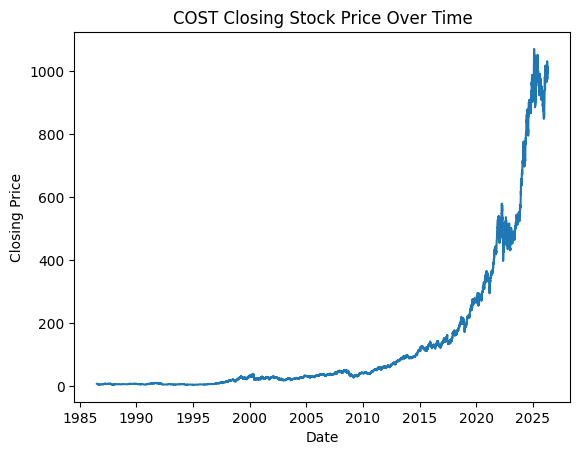

In [13]:
# Plotting Costco Closing Price
plt.plot(cost_data.index, cost_data["Close"])
plt.title("COST Closing Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

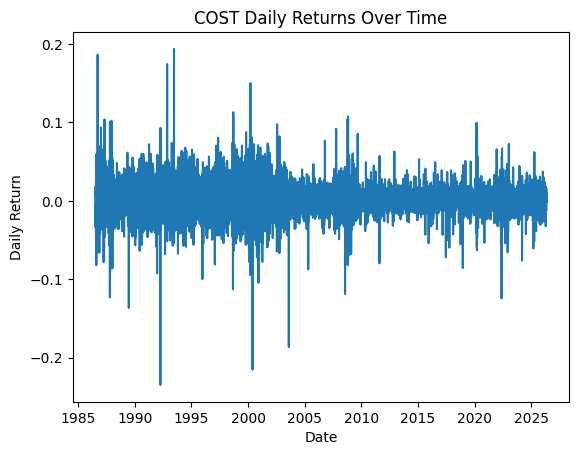

In [14]:
# Calculate and Plot Daily Returns
cost_data["Daily_Return"] = cost_data["Close"].pct_change()
plt.plot(cost_data.index, cost_data["Daily_Return"])
plt.title("COST Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

In [16]:
# COST Recent Returns
cost_data["Return_1D"] = cost_data["Close"].pct_change()
cost_data["Return_5D"] = cost_data["Close"].pct_change(5)
cost_data["Return_10D"] = cost_data["Close"].pct_change(10)
cost_data["Return_20D"] = cost_data["Close"].pct_change(20)
cost_data["Return_50D"] = cost_data["Close"].pct_change(50)
cost_data[["Close", "Return_1D", "Return_5D", "Return_10D", "Return_20D", "Return_50D"]].tail()

,Close,Return_1D,Return_5D,Return_10D,Return_20D,Return_50D
Date,,,,,,
2026-04-27 00:00:00-04:00,996.563965,-0.012995,0.000170,0.017495,0.014382,-0.000851
2026-04-28 00:00:00-04:00,992.559753,-0.004018,-0.011742,0.019696,-0.002589,-0.024036
2026-04-29 00:00:00-04:00,997.222961,0.004698,-0.005012,0.014136,0.002248,-0.013221
2026-04-30 00:00:00-04:00,1013.060059,0.015881,0.000148,0.027674,0.018032,0.018523
2026-05-01 00:00:00-04:00,1011.700012,-0.001343,0.001996,0.013279,-0.001766,0.025661


In [17]:
# COST Stock Volatility
cost_data["Volatility_5D"] = cost_data["Return_1D"].rolling(window=5).std()
cost_data["Volatility_10D"] = cost_data["Return_1D"].rolling(window=10).std()
cost_data["Volatility_20D"] = cost_data["Return_1D"].rolling(window=20).std()
cost_data["Volatility_50D"] = cost_data["Return_1D"].rolling(window=50).std()
cost_data[["Return_1D", "Volatility_5D","Volatility_10D", "Volatility_20D", "Volatility_50D"]].tail()

,Return_1D,Volatility_5D,Volatility_10D,Volatility_20D,Volatility_50D
Date,,,,,
2026-04-27 00:00:00-04:00,-0.012995,0.009492,0.008478,0.012288,0.011253
2026-04-28 00:00:00-04:00,-0.004018,0.008450,0.008279,0.011988,0.010904
2026-04-29 00:00:00-04:00,0.004698,0.009024,0.007843,0.012035,0.010894
2026-04-30 00:00:00-04:00,0.015881,0.010833,0.009088,0.012536,0.010890
2026-05-01 00:00:00-04:00,-0.001343,0.010725,0.008423,0.011845,0.010821


In [18]:
# COST Stock Volume 
cost_data["Volume_Change"] = cost_data["Volume"].pct_change()
cost_data["Volume_5D_Avg"] = cost_data["Volume"].rolling(window=5).mean()
cost_data["Volume_vs_5D_Avg"] = cost_data["Volume"] / cost_data["Volume_5D_Avg"] - 1
cost_data[["Volume", "Volume_Change","Volume_5D_Avg", "Volume_vs_5D_Avg"]].tail()

,Volume,Volume_Change,Volume_5D_Avg,Volume_vs_5D_Avg
Date,,,,
2026-04-27 00:00:00-04:00,1620400,-0.044125,1493720.0,0.084808
2026-04-28 00:00:00-04:00,1776000,0.096026,1575500.0,0.127261
2026-04-29 00:00:00-04:00,1516900,-0.145890,1635840.0,-0.072709
2026-04-30 00:00:00-04:00,2049300,0.350979,1731560.0,0.183499
2026-05-01 00:00:00-04:00,1508700,-0.263797,1694260.0,-0.109523


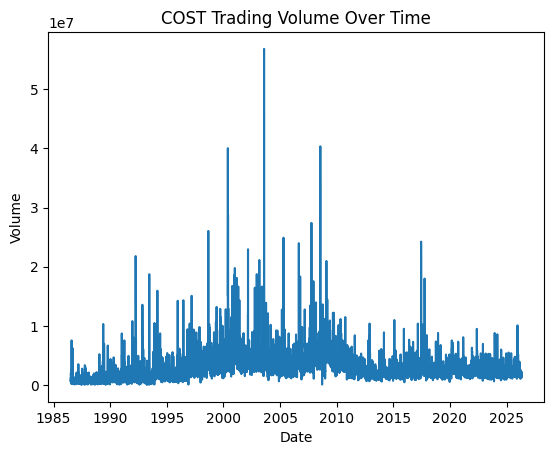

In [19]:
# Plotting COST Stock Volume
plt.plot(cost_data.index, cost_data["Volume"])
plt.title("COST Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [20]:
# Intraday Price Range
cost_data["High_Low_Range"] = (cost_data["High"] - cost_data["Low"]) / cost_data["Close"]
cost_data[["High", "Low", "Close", "High_Low_Range"]].tail()

,High,Low,Close,High_Low_Range
Date,,,,
2026-04-27 00:00:00-04:00,1012.940166,995.185959,996.563965,0.017815
2026-04-28 00:00:00-04:00,1011.182755,984.571345,992.559753,0.026811
2026-04-29 00:00:00-04:00,997.522515,983.692607,997.222961,0.013868
2026-04-30 00:00:00-04:00,1016.215453,994.876421,1013.060059,0.021064
2026-05-01 00:00:00-04:00,1031.270020,1006.320007,1011.700012,0.024661


In [21]:
# Next Day Return
cost_data["Next_Day_Return"] = cost_data["Return_1D"].shift(-1)
cost_data[["Return_1D", "Next_Day_Return"]].tail()

,Return_1D,Next_Day_Return
Date,,
2026-04-27 00:00:00-04:00,-0.012995,-0.004018
2026-04-28 00:00:00-04:00,-0.004018,0.004698
2026-04-29 00:00:00-04:00,0.004698,0.015881
2026-04-30 00:00:00-04:00,0.015881,-0.001343
2026-05-01 00:00:00-04:00,-0.001343,NaN


In [25]:
# Predicting Next Day Return using Linear Regression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Training Model for Linear Prediction
model_data = cost_data[
    [
        "Return_1D",
        "Return_5D", 
        "Return_10D", 
        "Return_20D", 
        "Return_50D",
        "Volume_Change",
        "Volume_vs_5D_Avg",
        "Next_Day_Return"
    ]
].dropna()

split_index = int(len(model_data) * 0.8)
train = model_data.iloc[:split_index]
test = model_data.iloc[split_index:]

X_train = train[ 
    [ "Return_1D", 
      "Return_5D", 
      "Return_10D", 
      "Return_20D", 
      "Return_50D", 
      "Volume_Change", 
      "Volume_vs_5D_Avg" 
    ] 
]

y_train = train["Next_Day_Return"]

X_test = test[ 
    [ "Return_1D", 
      "Return_5D", 
      "Return_10D", 
      "Return_20D", 
      "Return_50D", 
      "Volume_Change", 
      "Volume_vs_5D_Avg" 
    ] 
]

y_test = test["Next_Day_Return"]

# Creating Regression Model
regressor = LinearRegression()
# fit linear regression model
model = regressor.fit(X_train, y_train)
# Creating Prediction using model
predictions = model.predict(X_test)

In [26]:
# Evaluating Model Performance
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Squared Error: 0.00020464407055316588
Mean Absolute Error: 0.00993672639403228
R-squared: 0.0009090697513388646


In [27]:
# Comparing actual vs predicted returns
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.head()

,Actual,Predicted
Date,,
2018-05-22 00:00:00-04:00,-0.004171,-0.000059
2018-05-23 00:00:00-04:00,0.003785,0.000563
2018-05-24 00:00:00-04:00,-0.002665,0.000565
2018-05-25 00:00:00-04:00,-0.008167,0.000384
2018-05-29 00:00:00-04:00,0.014740,0.000761


In [29]:
# Predicting COST Stock Price for the Next Trading Day (May 4, 2026)
predicted_next_day_return = model.predict(
    cost_data[
        [
            "Return_1D",
            "Return_5D",
            "Return_10D",
            "Return_20D",
            "Return_50D",
            "Volume_Change",
            "Volume_vs_5D_Avg"
        ]
    ].dropna().tail(1)
)[0]

# last closing stock price
last_close_price = cost_data["Close"].dropna().iloc[-1]

# predicting next day stock price
predicted_next_day_price = last_close_price * (1 + predicted_next_day_return)

print("Last Close Price:", last_close_price)
print("Predicted Next-Day Return:", predicted_next_day_return)
print("Predicted Next-Day Price:", predicted_next_day_price)

Last Close Price: 1011.7000122070312
Predicted Next-Day Return: 0.0005116510740219289
Predicted Next-Day Price: 1012.217649604865


In [30]:
# Direction of next day prediction
if predicted_next_day_return > 0:
    print("Model predicts COST will go up next trading day.")
else:
    print("Model predicts COST will go down next trading day.")

Model predicts COST will go up next trading day.


In [31]:
from sklearn.metrics import precision_score

actual_direction = (y_test > 0).astype(int)
predicted_direction = (predictions > 0).astype(int)

precision = precision_score(actual_direction, predicted_direction)

print("Precision Score:", precision)

Precision Score: 0.545819397993311


In [32]:
# Baseline Model: 'no-change' forecast
baseline_predictions = np.zeros(len(y_test))
baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline Mean Squared Error:", baseline_mse)
print("Baseline Mean Absolute Error:", baseline_mae)
print("Baseline R-squared:", baseline_r2)

Baseline Mean Squared Error: 0.0002057739982191744
Baseline Mean Absolute Error: 0.009957130914689038
Baseline R-squared: -0.004607339690159584


In [33]:
# Comparing Baseline with Actual Model
comparison = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression"],
    "MSE": [baseline_mse, mse],
    "MAE": [baseline_mae, mae],
    "R2": [baseline_r2, r2]
})

comparison

,Model,MSE,MAE,R2
0,Baseline,0.000206,0.009957,-0.004607
1,Linear Regression,0.000205,0.009937,0.000909


In [34]:
# Direction Accuracy
actual_direction = (y_test > 0).astype(int)
predicted_direction = (predictions > 0).astype(int)

direction_accuracy = (actual_direction == predicted_direction).mean()

print("Direction Accuracy:", direction_accuracy)
print("Precision Score:", precision)

Direction Accuracy: 0.5225450901803608
Precision Score: 0.545819397993311


In [3]:
# Checking Next-Day Prediction Against Actual Price
import yfinance as yf
predicted_next_day_return = 0.0005116510740219289
predicted_next_day_price = 1012.217649604865
last_close_price = 1011.7000122070312

cost = yf.Ticker("COST")
updated_cost = cost.history(start="2026-05-01", end="2026-05-06")
updated_cost[["Close"]]

,Close
Date,
2026-05-01 00:00:00-04:00,1011.700012
2026-05-04 00:00:00-04:00,1012.789978


In [5]:
# Next Day Prediction Check
actual_next_day_price = updated_cost.loc["2026-05-04", "Close"]
actual_next_day_return = (actual_next_day_price - last_close_price) / last_close_price

price_error = actual_next_day_price - predicted_next_day_price
return_error = actual_next_day_return - predicted_next_day_return

direction_correct = (actual_next_day_return > 0) == (predicted_next_day_return > 0)

print("Predicted Next-Day Price:", predicted_next_day_price)
print("Actual Next-Day Price:", actual_next_day_price)
print("Price Error:", price_error)

print("Predicted Next-Day Return:", predicted_next_day_return)
print("Actual Next-Day Return:", actual_next_day_return)
print("Return Error:", return_error)

print("Predicted Direction Correct:", direction_correct)

Predicted Next-Day Price: 1012.217649604865
Actual Next-Day Price: 1012.7899780273438
Price Error: 0.5723284224787903
Predicted Next-Day Return: 0.0005116510740219289
Actual Next-Day Return: 0.0010773606871217994
Return Error: 0.0005657096130998705
Predicted Direction Correct: True


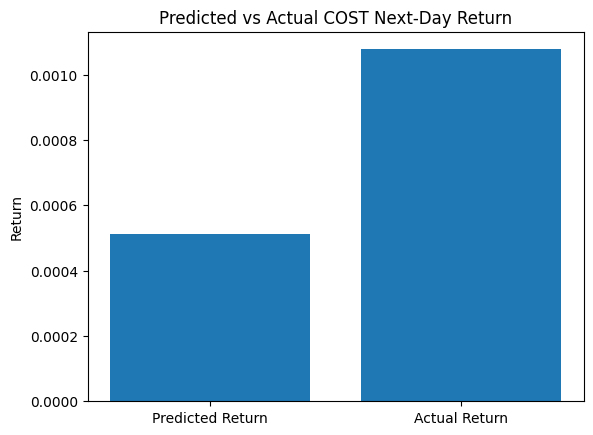

In [8]:
# Plotting Predicted vs Actual Next-Day Return 
import matplotlib.pyplot as plt
plt.bar(
    ["Predicted Return", "Actual Return"],
    [predicted_next_day_return, actual_next_day_return]
)
plt.title("Predicted vs Actual COST Next-Day Return")
plt.ylabel("Return")
plt.show()